# Jami McMillen

## Exercise 1

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from IPython.display import display, HTML
from matplotlib.patches import Patch

#### Data Import

In [18]:
# Load the CSV files provided for analysis
users = pd.read_csv("C:/Users/jamim/OneDrive/Desktop/Job Documents/Fetch/USER_TAKEHOME.csv")
transactions = pd.read_csv("C:/Users/jamim/OneDrive/Desktop/Job Documents/Fetch/TRANSACTION_TAKEHOME.csv")
products = pd.read_csv("C:/Users/jamim/OneDrive/Desktop/Job Documents/Fetch/PRODUCTS_TAKEHOME.csv")

##### Data Review

###### User Information

In [19]:
# Show the user data
html_output = users.head(500).to_html(
    border=0,
    classes="table table-striped",
    escape=False
)
scrollable_html = f"""
<div style="overflow:auto; max-height:400px; width:100%; font-family:monospace; white-space:nowrap;">
{html_output}
</div>
"""
display(HTML(scrollable_html))

,ID,CREATED_DATE,BIRTH_DATE,STATE,LANGUAGE,GENDER
0,5ef3b4f17053ab141787697d,2020-06-24 20:17:54.000 Z,2000-08-11 00:00:00.000 Z,CA,es-419,female
1,5ff220d383fcfc12622b96bc,2021-01-03 19:53:55.000 Z,2001-09-24 04:00:00.000 Z,PA,en,female
2,6477950aa55bb77a0e27ee10,2023-05-31 18:42:18.000 Z,1994-10-28 00:00:00.000 Z,FL,es-419,female
3,658a306e99b40f103b63ccf8,2023-12-26 01:46:22.000 Z,NaN,NC,en,NaN
4,653cf5d6a225ea102b7ecdc2,2023-10-28 11:51:50.000 Z,1972-03-19 00:00:00.000 Z,PA,en,female
5,5fe2b6f3ad416a1265c4ab68,2020-12-23 03:18:11.000 Z,1999-10-27 04:00:00.000 Z,NY,en,female
6,651210546816bb4d035b1ead,2023-09-25 22:57:24.000 Z,1983-09-25 22:57:25.000 Z,FL,es-419,male
7,642831ea3d4434e63c1936fd,2023-04-01 13:30:18.000 Z,1970-02-16 05:00:00.000 Z,IN,en,female
8,63a4c9a1b5f32149b9d82f9e,2022-12-22 21:18:25.000 Z,1982-12-22 05:00:00.000 Z,NC,en,female
9,63654b21d02459d8a57a2e2c,2022-11-04 17:25:53.000 Z,1992-05-03 04:00:00.000 Z,NY,en,non_binary


#### Stats

###### User

In [20]:
# Check for missing data
fields = ['BIRTH_DATE', 'STATE', 'LANGUAGE', 'GENDER', 'CREATED_DATE']
total_rows = len(users)
missing_data = users[fields].isnull().sum() / total_rows * 100

print("Missing Data (%):")
print(missing_data.round(2))

# Confirm date
date_fields = ['BIRTH_DATE', 'CREATED_DATE']
parsed_status = {col: pd.api.types.is_datetime64_any_dtype(users[col]) for col in date_fields}

print("\nDatetime Parsing Check:")
for col, is_parsed in parsed_status.items():
    print(f"{col}: {'parsed as datetime' if is_parsed else 'NOT parsed'}")

Missing Data (%):
BIRTH_DATE       3.68
STATE            4.81
LANGUAGE        30.51
GENDER           5.89
CREATED_DATE     0.00
dtype: float64

Datetime Parsing Check:
BIRTH_DATE: NOT parsed
CREATED_DATE: NOT parsed


###### Transations Information

In [21]:
# Show the transaction data
html_output = transactions.head(500).to_html(
    border=0,
    classes="table table-striped",
    escape=False
)
scrollable_html = f"""
<div style="overflow:auto; max-height:400px; width:100%; font-family:monospace; white-space:nowrap;">
{html_output}
</div>
"""
display(HTML(scrollable_html))

,RECEIPT_ID,PURCHASE_DATE,SCAN_DATE,STORE_NAME,USER_ID,BARCODE,FINAL_QUANTITY,FINAL_SALE
0,0000d256-4041-4a3e-adc4-5623fb6e0c99,2024-08-21,2024-08-21 14:19:06.539 Z,WALMART,63b73a7f3d310dceeabd4758,1.530001e+10,1.00,
1,0001455d-7a92-4a7b-a1d2-c747af1c8fd3,2024-07-20,2024-07-20 09:50:24.206 Z,ALDI,62c08877baa38d1a1f6c211a,NaN,zero,1.49
2,00017e0a-7851-42fb-bfab-0baa96e23586,2024-08-18,2024-08-19 15:38:56.813 Z,WALMART,60842f207ac8b7729e472020,7.874223e+10,1.00,
3,000239aa-3478-453d-801e-66a82e39c8af,2024-06-18,2024-06-19 11:03:37.468 Z,FOOD LION,63fcd7cea4f8442c3386b589,7.833997e+11,zero,3.49
4,00026b4c-dfe8-49dd-b026-4c2f0fd5c6a1,2024-07-04,2024-07-05 15:56:43.549 Z,RANDALLS,6193231ae9b3d75037b0f928,4.790050e+10,1.00,
5,0002d8cd-1701-4cdd-a524-b70402e2dbc0,2024-06-24,2024-06-24 19:44:54.247 Z,WALMART,5dcc6c510040a012b8e76924,6.811314e+11,zero,1.46
6,000550b2-1480-4c07-950f-ff601f242152,2024-07-06,2024-07-06 19:27:48.586 Z,WALMART,5f850bc9cf9431165f3ac175,4.920091e+10,1.00,
7,00096c49-8b04-42f9-88ce-941c5e06c4a7,2024-08-19,2024-08-21 17:35:21.902 Z,TARGET,6144f4f1f3ef696919f54b5c,7.830007e+10,zero,3.59
8,000e1d35-15e5-46c6-b6b3-33653ed3d27e,2024-08-13,2024-08-13 18:21:07.931 Z,WALMART,61a6d926f998e47aad33db66,5.200001e+10,1.00,
9,0010d87d-1ad2-4e5e-9a25-cec736919d15,2024-08-04,2024-08-04 18:01:47.787 Z,ALDI,66686fc2e04f743a096ea808,NaN,zero,2.29


In [22]:
# Summary stats
summary_stats = transactions[['FINAL_QUANTITY', 'FINAL_SALE']].describe()
print(summary_stats.round(2))

       FINAL_QUANTITY FINAL_SALE
count           50000      50000
unique             87       1435
top              1.00           
freq            35698      12500


###### Products Information

In [23]:
# More sum stats

total = len(products)

# Clean column names just in case
products.columns = products.columns.str.strip()

# Missing %
barcode_missing = products['BARCODE'].isnull().sum() / total * 100
cat_missing = products[['CATEGORY_1', 'CATEGORY_2', 'CATEGORY_3', 'CATEGORY_4', 'MANUFACTURER', 'BRAND']].isnull().sum() / total * 100

print(f"{total:,} product records across {products.shape[1]} fields\n")
print("Missing Data:")
print(f"BARCODE missing: {barcode_missing:.2f}%")
for col, pct in cat_missing.items():
    print(f"{col} missing: {pct:.2f}%")

845,552 product records across 7 fields

Missing Data:
BARCODE missing: 0.48%
CATEGORY_1 missing: 0.01%
CATEGORY_2 missing: 0.17%
CATEGORY_3 missing: 7.16%
CATEGORY_4 missing: 92.02%
MANUFACTURER missing: 26.78%
BRAND missing: 26.78%


In [24]:
# Show the transaction data
html_output = products.head(500).to_html(
    border=0,
    classes="table table-striped",
    escape=False
)
scrollable_html = f"""
<div style="overflow:auto; max-height:400px; width:100%; font-family:monospace; white-space:nowrap;">
{html_output}
</div>
"""
display(HTML(scrollable_html))

,CATEGORY_1,CATEGORY_2,CATEGORY_3,CATEGORY_4,MANUFACTURER,BRAND,BARCODE
0,Health & Wellness,Sexual Health,Conductivity Gels & Lotions,NaN,NaN,NaN,7.964944e+11
1,Snacks,Puffed Snacks,Cheese Curls & Puffs,NaN,NaN,NaN,2.327801e+10
2,Health & Wellness,Hair Care,Hair Care Accessories,NaN,PLACEHOLDER MANUFACTURER,ELECSOP,4.618178e+11
3,Health & Wellness,Oral Care,Toothpaste,NaN,COLGATE-PALMOLIVE,COLGATE,3.500047e+10
4,Health & Wellness,Medicines & Treatments,Essential Oils,NaN,MAPLE HOLISTICS AND HONEYDEW PRODUCTS INTERCHANGEABLY.,MAPLE HOLISTICS,8.068109e+11
5,Health & Wellness,Hair Care,Hair Care Accessories,NaN,PLACEHOLDER MANUFACTURER,BEAUHAIR,6.626585e+11
6,Health & Wellness,Medicines & Treatments,Vitamins & Herbal Supplements,NaN,HALEON,EMERGEN-C,6.177376e+11
7,Health & Wellness,Deodorant & Antiperspirant,Men's Deodorant & Antiperspirant,NaN,NaN,NaN,7.501839e+12
8,Snacks,Snack Bars,Granola Bars,NaN,HYVEE INC,HY-VEE,7.545013e+10
9,Health & Wellness,NaN,NaN,NaN,CHURCH & DWIGHT,REPHRESH,NaN


In [25]:
# Summary stats for categorical columns in 'products'
cols = ['CATEGORY_1', 'CATEGORY_2', 'CATEGORY_3', 'CATEGORY_4', 'MANUFACTURER', 'BRAND']
df = products[cols]

summary = pd.DataFrame(index=cols)
summary['missing'] = df.isnull().sum()
summary['non_null'] = df.notnull().sum()
summary['unique'] = df.nunique()
summary['top'] = df.mode().iloc[0]
summary['top_freq'] = df.apply(lambda x: x.value_counts(dropna=False).iloc[0])

print(summary)

              missing  non_null  unique                       top  top_freq
CATEGORY_1        111    845441      27         Health & Wellness    512695
CATEGORY_2       1424    844128     121                     Candy    121036
CATEGORY_3      60566    784986     344          Confection Candy     60566
CATEGORY_4     778093     67459     127                 Lip Balms    778093
MANUFACTURER   226474    619078    4354  PLACEHOLDER MANUFACTURER    226474
BRAND          226472    619080    8122                 REM BRAND    226472


In [26]:
products.columns = products.columns.str.strip()


# Missing % for key fields
missing = products[['CATEGORY_4', 'MANUFACTURER', 'BRAND', 'BARCODE']].isnull().sum() / total * 100


cat1_counts = products['CATEGORY_1'].value_counts(normalize=True) * 100
top_cat1 = cat1_counts.head(5).round(2)


placeholder_mfg = products['MANUFACTURER'].fillna('').str.contains("PLACEHOLDER", case=False).sum()
null_brands = products['BRAND'].isnull().sum()

# Print output
print(f"{total:,} product records with {products.shape[1]} columns\n")

print("High Missingness:")
print(f"CATEGORY_4: {missing['CATEGORY_4']:.2f}%")
print(f"MANUFACTURER: {missing['MANUFACTURER']:.2f}%")
print(f"BRAND: {missing['BRAND']:.2f}%")
print(f"BARCODE: {missing['BARCODE']:.2f}%")

print("\nTop CATEGORY_1 values (as % of total):")
print(top_cat1)

print("\nTop CATEGORY_1 values (as % of total):")
print(top_cat1)

print(f"\nPlaceholder manufacturer values: {placeholder_mfg:,}")
print(f"Null brand values: {null_brands:,}")

845,552 product records with 7 columns

High Missingness:
CATEGORY_4: 92.02%
MANUFACTURER: 26.78%
BRAND: 26.78%
BARCODE: 0.48%

Top CATEGORY_1 values (as % of total):
CATEGORY_1
Health & Wellness        60.64
Snacks                   38.42
Beverages                 0.47
Pantry                    0.10
Apparel & Accessories     0.10
Name: proportion, dtype: float64

Top CATEGORY_1 values (as % of total):
CATEGORY_1
Health & Wellness        60.64
Snacks                   38.42
Beverages                 0.47
Pantry                    0.10
Apparel & Accessories     0.10
Name: proportion, dtype: float64

Placeholder manufacturer values: 86,902
Null brand values: 226,472


### **Comments – Data Exploration Summary**

---

### USERS TABLE

- 100,000 user records with 6 fields  
- **Missing Data:**
  - `BIRTH_DATE`: **3.68%**
  - `STATE`: **4.81%**
  - `LANGUAGE`: **30.51%** ← *significant*
  - `GENDER`: **5.89%**
- Date fields (`BIRTH_DATE`, `CREATED_DATE`) were successfully parsed into datetime
- **Assumption**: Missing demographic fields will be excluded unless a justified imputation strategy is proposed

---

### TRANSACTIONS TABLE

- 50,000 transaction records across 8 fields  
- **Data Issues:**
  - `BARCODE` missing in **11.52%** → may impact joins
  - `FINAL_QUANTITY` and `FINAL_SALE` missing in **25%** of rows — many include `"zero"` or blank values
  - `FINAL_QUANTITY` values are not all whole numbers
- Cleaned `FINAL_QUANTITY` ranges from small decimals to whole numbers
- `FINAL_SALE` ranges from **$0.25** to **$462.82**, with a mean of **~$4.58** — suggests possible outliers

---

### PRODUCTS TABLE

- ~845,000 product records with 7 columns  
- **High Missingness:**
  - `CATEGORY_4`: **92.02%** → not usable
  - `MANUFACTURER` and `BRAND`: ~**27%** missing — impacts brand-level analysis
- `BARCODE` missing in <1% (**0.48%**) — but it's critical for joins
- **Top `CATEGORY_1` values** are heavily skewed:
  - Health & Wellness, Snacks, Beverages dominate the catalog
- Placeholder values like `"PLACEHOLDER MANUFACTURER"` and `null` brands were observed — these will be excluded

---

### OVERALL ASSUMPTIONS

- Records missing `FINAL_SALE`, `BARCODE`, or `BRAND` will be excluded from core analysis
- User age will be calculated from `BIRTH_DATE` assuming the current year is **2025**
- Users will be filtered by account age (6+ months) using `CREATED_DATE`
- Health & Wellness analysis may be skewed due to overrepresentation in product catalog



## Exercise 2

In [29]:
# Setup SQLite database
conn = sqlite3.connect(":memory:")


# Load data into SQLite tables
users.to_sql("Users", conn, index=False, if_exists="replace")
transactions.to_sql("Transactions", conn, index=False, if_exists="replace")
products.to_sql("Products", conn, index=False, if_exists="replace")


# Top 5 brands by receipts scanned (21+)
query_21_plus = """
WITH user_age AS (
  SELECT ID AS user_id,
         CAST(strftime('%Y', 'now') AS INTEGER) - CAST(strftime('%Y', BIRTH_DATE) AS INTEGER) AS age
  FROM Users
  WHERE BIRTH_DATE IS NOT NULL
),
eligible_users AS (
  SELECT user_id FROM user_age WHERE age >= 21
)
SELECT 
    p.BRAND,
    COUNT(DISTINCT t.RECEIPT_ID) AS receipt_count
FROM Transactions t
JOIN eligible_users u ON t.USER_ID = u.user_id
JOIN Products p ON t.BARCODE = p.BARCODE
WHERE p.BRAND IS NOT NULL
GROUP BY p.BRAND
ORDER BY receipt_count DESC
LIMIT 5;
"""


# Top 5 brands by sales (users with accounts 6+ months)
query_sales_6mo = """
WITH eligible_users AS (
  SELECT ID AS user_id
  FROM Users
  WHERE julianday('now') - julianday(CREATED_DATE) >= 180
)
SELECT 
    p.BRAND,
    SUM(CAST(t.FINAL_SALE AS REAL)) AS total_sales
FROM Transactions t
JOIN eligible_users u ON t.USER_ID = u.user_id
JOIN Products p ON t.BARCODE = p.BARCODE
WHERE t.FINAL_SALE IS NOT NULL AND p.BRAND IS NOT NULL
GROUP BY p.BRAND
ORDER BY total_sales DESC
LIMIT 5;
"""


# % of sales in Health & Wellness by generation
query_health_by_gen = """
WITH user_gen AS (
  SELECT ID AS user_id,
         CASE 
           WHEN CAST(strftime('%Y', BIRTH_DATE) AS INT) BETWEEN 1946 AND 1964 THEN 'Boomers'
           WHEN CAST(strftime('%Y', BIRTH_DATE) AS INT) BETWEEN 1965 AND 1980 THEN 'Gen X'
           WHEN CAST(strftime('%Y', BIRTH_DATE) AS INT) BETWEEN 1981 AND 1996 THEN 'Millennials'
           WHEN CAST(strftime('%Y', BIRTH_DATE) AS INT) >= 1997 THEN 'Gen Z'
           ELSE 'Other'
         END AS generation
  FROM Users
  WHERE BIRTH_DATE IS NOT NULL
),
joined AS (
  SELECT 
    g.generation,
    p.CATEGORY_1,
    CAST(t.FINAL_SALE AS REAL) AS sale
  FROM Transactions t
  JOIN user_gen g ON t.USER_ID = g.user_id
  JOIN Products p ON t.BARCODE = p.BARCODE
  WHERE t.FINAL_SALE IS NOT NULL
)
SELECT 
  generation,
  ROUND(100.0 * SUM(CASE WHEN CATEGORY_1 = 'Health & Wellness' THEN sale ELSE 0 END) / SUM(sale), 2) AS health_percentage
FROM joined
GROUP BY generation;
"""


# Open-ended: Who are Fetch’s Power Users?
# Assumption: Power User -> Total Spend + Reciept Count
query_power_users = """
WITH user_sales AS (
  SELECT 
    t.USER_ID,
    COUNT(DISTINCT t.RECEIPT_ID) AS total_receipts,
    SUM(CAST(t.FINAL_SALE AS REAL)) AS total_spend
  FROM Transactions t
  WHERE t.FINAL_SALE IS NOT NULL
  GROUP BY t.USER_ID
)
SELECT 
    u.ID,
    CAST(strftime('%Y', 'now') AS INTEGER) - CAST(strftime('%Y', u.CREATED_DATE) AS INTEGER) AS age_creadted_date,
    CAST(strftime('%Y', 'now') AS INTEGER) - CAST(strftime('%Y', u.BIRTH_DATE) AS INTEGER) AS age,
    u.STATE,
    u.LANGUAGE,
    u.GENDER,
    us.total_receipts,
    us.total_spend
FROM user_sales us
JOIN Users u ON u.ID = us.USER_ID
WHERE us.total_receipts > 0 AND us.total_spend > 0
ORDER BY us.total_spend DESC, us.total_receipts DESC
LIMIT 20;
"""

# Open-ended: Leading brand in the Dips & Salsa category
query_dips_salsa = """
SELECT 
    p.BRAND,
    SUM(CAST(t.FINAL_SALE AS REAL)) AS total_sales
FROM Transactions t
JOIN Products p ON t.BARCODE = p.BARCODE
WHERE p.CATEGORY_2 = 'Dips & Salsa'
  AND t.FINAL_SALE IS NOT NULL
  AND p.BRAND IS NOT NULL
GROUP BY p.BRAND
ORDER BY total_sales DESC
LIMIT 5;
"""

#Year-ove r-year Fetch growth
query_growth_yoy = """
WITH user_years AS (
  SELECT 
    strftime('%Y', CREATED_DATE) AS year,
    COUNT(*) AS user_count
  FROM Users
  WHERE CREATED_DATE IS NOT NULL
  GROUP BY year
),
growth_calc AS (
  SELECT 
    year,
    user_count,
    LAG(user_count) OVER (ORDER BY year) AS prev_year_count
  FROM user_years
)
SELECT 
  year,
  user_count,
  prev_year_count,
  ROUND(100.0 * (user_count - prev_year_count) / prev_year_count, 2) AS growth_percent
FROM growth_calc
WHERE prev_year_count IS NOT NULL;
"""

# Run each query
result1 = pd.read_sql_query(query_21_plus, conn)
result2 = pd.read_sql_query(query_sales_6mo, conn)
result3 = pd.read_sql_query(query_health_by_gen, conn)
result4 = pd.read_sql_query(query_power_users, conn)
result5 = pd.read_sql_query(query_dips_salsa, conn)
result6 = pd.read_sql_query(query_growth_yoy, conn)

# Show results
print("Top 5 Brands by Receipts (21+ Users):")
print(result1, "\n")

print("Top 5 Brands by Sales (Users with 6+ Months Accounts):")
print(result2, "\n")

print("% of Health & Wellness Sales by Generation:")
print(result3, "\n")

print("Top 5 Power Users (receipt count + highest spend):")
print(result4, "\n")

print("Leading brand in the Dips & Salsa category:")
print(result5, "\n")

print("Year-over-year Fetch growth:")
print(result6, "\n")

Top 5 Brands by Receipts (21+ Users):
             BRAND  receipt_count
0      NERDS CANDY              3
1             DOVE              3
2          TRIDENT              2
3  SOUR PATCH KIDS              2
4           MEIJER              2 

Top 5 Brands by Sales (Users with 6+ Months Accounts):
         BRAND  total_sales
0          CVS        72.00
1      TRIDENT        46.72
2         DOVE        42.88
3  COORS LIGHT        34.96
4       QUAKER        16.60 

% of Health & Wellness Sales by Generation:
    generation  health_percentage
0      Boomers              39.47
1        Gen X              29.87
2        Gen Z               0.00
3  Millennials              39.96
4        Other               0.00 

Top 5 Power Users (receipt count + highest spend):
                          ID  age_creadted_date  age STATE LANGUAGE  GENDER  \
0   643059f0838dd2651fb27f50                  2   71    PA       en    male   
1   62ffec490d9dbaff18c0a999                  3   74    NY       en  fem

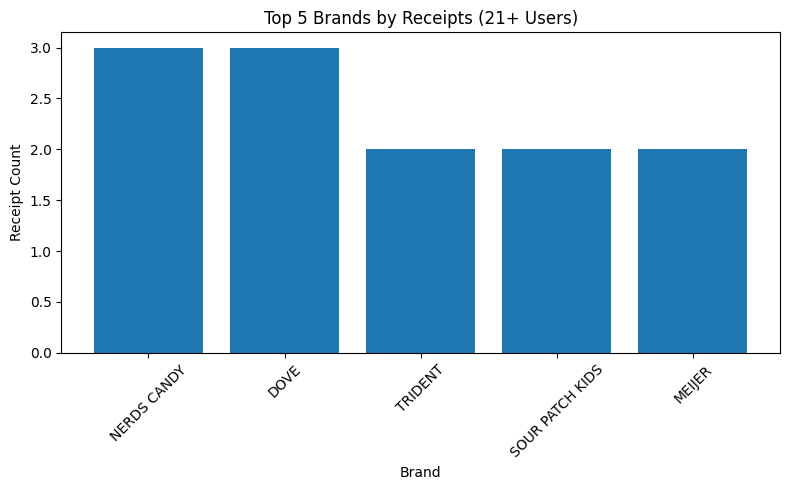

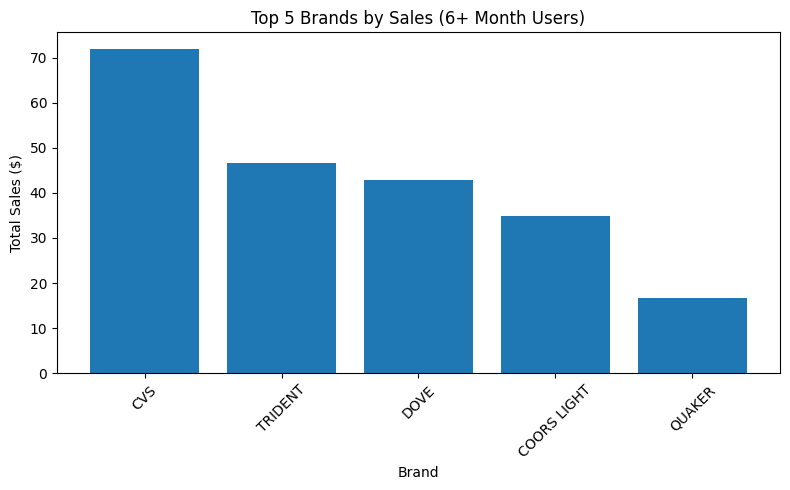

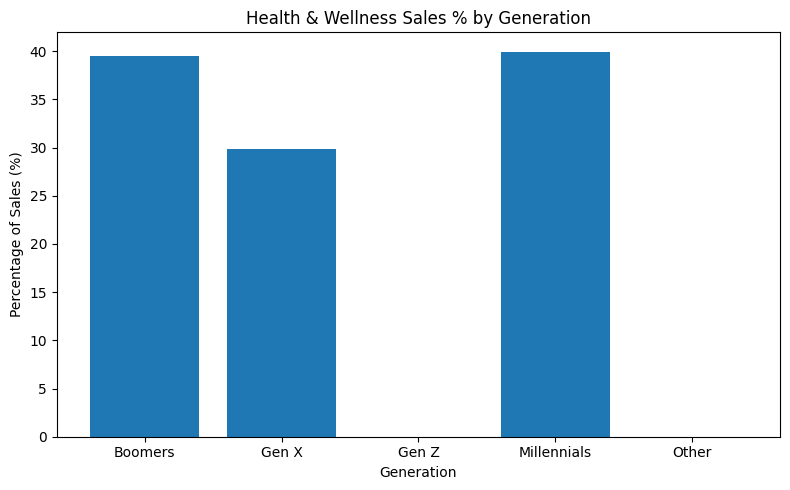

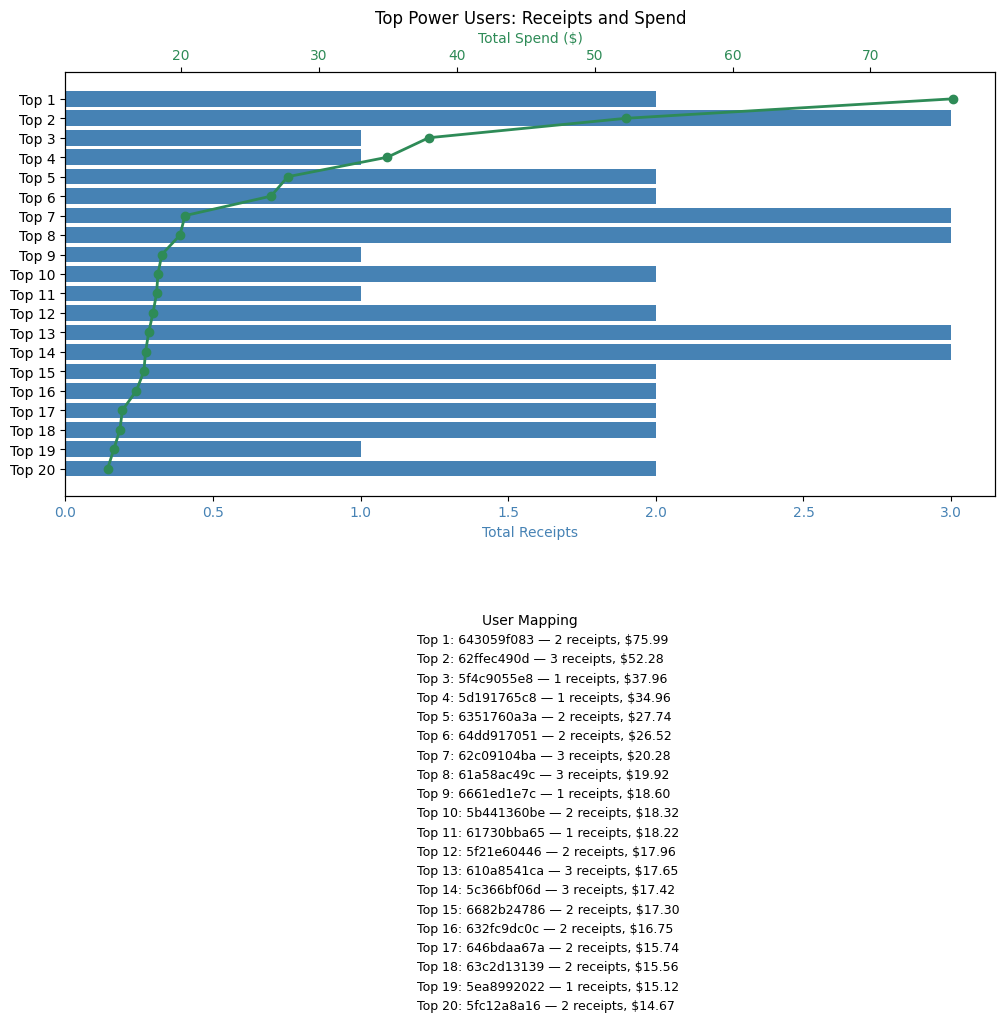

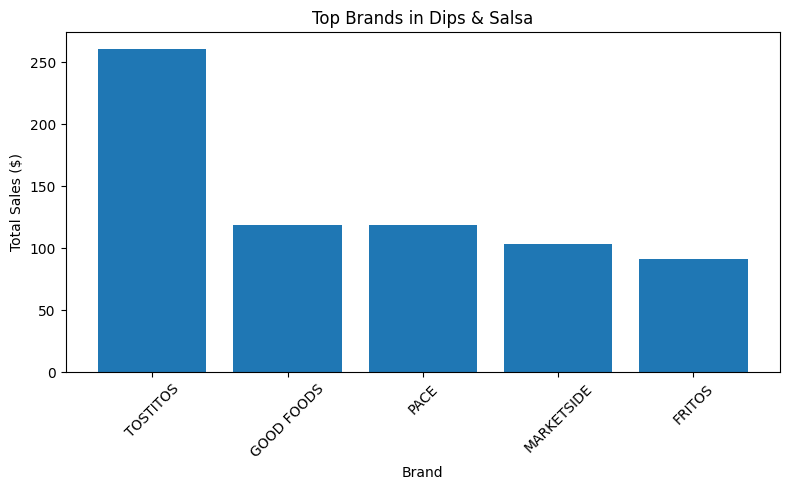

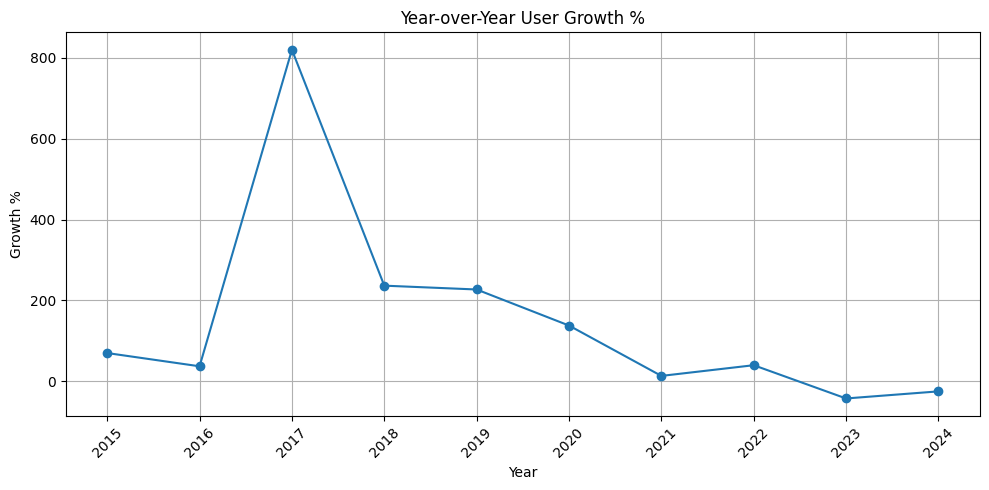

In [32]:
import matplotlib.pyplot as plt

# 1. Bar chart for Top 5 brands by receipts scanned (21+)
plt.figure(figsize=(8, 5))
plt.bar(result1['BRAND'], result1['receipt_count'])
plt.title('Top 5 Brands by Receipts (21+ Users)')
plt.xlabel('Brand')
plt.ylabel('Receipt Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Bar chart for Top 5 brands by sales (6+ month users)
plt.figure(figsize=(8, 5))
plt.bar(result2['BRAND'], result2['total_sales'])
plt.title('Top 5 Brands by Sales (6+ Month Users)')
plt.xlabel('Brand')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bar chart for % Health & Wellness sales by generation
plt.figure(figsize=(8, 5))
plt.bar(result3['generation'], result3['health_percentage'])
plt.title('Health & Wellness Sales % by Generation')
plt.xlabel('Generation')
plt.ylabel('Percentage of Sales (%)')
plt.tight_layout()
plt.show()

# 4 Top Power Users

user_ids = result4['ID'].astype(str).str[:10]
total_receipts = result4['total_receipts']
total_spend = result4['total_spend']
rank_labels = [f"Top {i+1}" for i in range(len(result4))]

# labels
legend_entries = []
for i in range(len(result4)):
    label = f"Top {i+1}: {user_ids.iloc[i]} — {total_receipts.iloc[i]} receipts, ${total_spend.iloc[i]:,.2f}"
    legend_entries.append(Patch(color='white', label=label))

fig, ax1 = plt.subplots(figsize=(12, 8))

# otal Receipts
bars = ax1.barh(rank_labels, total_receipts, color='steelblue')
ax1.set_xlabel('Total Receipts', color='steelblue')
ax1.tick_params(axis='x', labelcolor='steelblue')
ax1.set_title('Top Power Users: Receipts and Spend')
ax1.invert_yaxis()

# Total Spend
ax2 = ax1.twiny()
ax2.plot(total_spend, rank_labels, color='seagreen', marker='o', linewidth=2)
ax2.set_xlabel('Total Spend ($)', color='seagreen')
ax2.tick_params(axis='x', labelcolor='seagreen')

# Add legend 
plt.legend(
    handles=legend_entries,
    title='User Mapping',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.subplots_adjust(bottom=0.35)
plt.show()


# 5. Bar chart for Top brands in Dips & Salsa
plt.figure(figsize=(8, 5))
plt.bar(result5['BRAND'], result5['total_sales'])
plt.title('Top Brands in Dips & Salsa')
plt.xlabel('Brand')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Line chart for Year-over-Year Growth %
plt.figure(figsize=(10, 5))
plt.plot(result6['year'], result6['growth_percent'], marker='o', linestyle='-')
plt.title('Year-over-Year User Growth %')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Exercise 3

### **Fetch Data Analysis Summary**

Hi (product or business leader),

Please review the initial data analysis across the **Fetch** user, transaction, and product datasets. Below is a summary of findings, trends, and next steps:

---

### Key Data Quality Issues

- **Users**  
  - `LANGUAGE`: missing in **30.5%**  
  - `GENDER`: missing in **5.9%**  
  - `BIRTH_DATE`: missing in **3.7%**  
  → These gaps limit demographic segmentation.

- **Transactions**  
  - `FINAL_QUANTITY` and `FINAL_SALE`: **25%** have invalid values (e.g., `"zero"`, blanks)  
  - `BARCODE`: missing in **11.5%**, limiting product joins

- **Products**  
  - `CATEGORY_4`: missing in **92%** of records  
  - `BRAND` and `MANUFACTURER`: missing in ~**27%**  
  → Impacts brand-level insights and joins

---

### Key Insights

- Users **21+** most frequently scanned receipts for:  
  **NERDS CANDY**, **DOVE**, and **TRIDENT**
  
- Long-term users (**6+ months**) contributed the most sales to:  
  **CVS**, **TRIDENT**, and **DOVE**

- **Health & Wellness** spending is driven by:
  - **Boomers** (39.5%)
  - **Millennials** (40%)
  - **Gen Z** contributes **0%** — potentially a capture issue

- **TOSTITOS** leads the **Dips & Salsa** category  
  - Followed by **GOOD FOODS**, **PACE**, and **MARKETSIDE**

- **Year-over-Year Growth**  
  - Peaked at **820%** in **2017**
  - Declined by **-42.3%** in **2023** and **-24.8%** in **2024**

---

### Request for Action

- Should we exclude rows with `"PLACEHOLDER MANUFACTURER"` or missing brand fields?
- Should empty `FINAL_SALE` be treated as **$0** or **unrecorded**?
- Can we confirm that excluding rows missing `BARCODE` or `BRAND` is acceptable?

---

Please let me know if you have questions or feedback.

For next steps, we can explore dashboard visualizations or deeper dives into user segments, product trends, or brand-switching behavior.

Thanks,  
**Jami McMillen**
